WE DO REGRESSION AND FIND NO. OF PASSENGERS DIED IN TITANIC INCIDENT

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd
import sklearn 
from matplotlib import style
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC,LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train_df.describe(
)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train_df.head(30)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


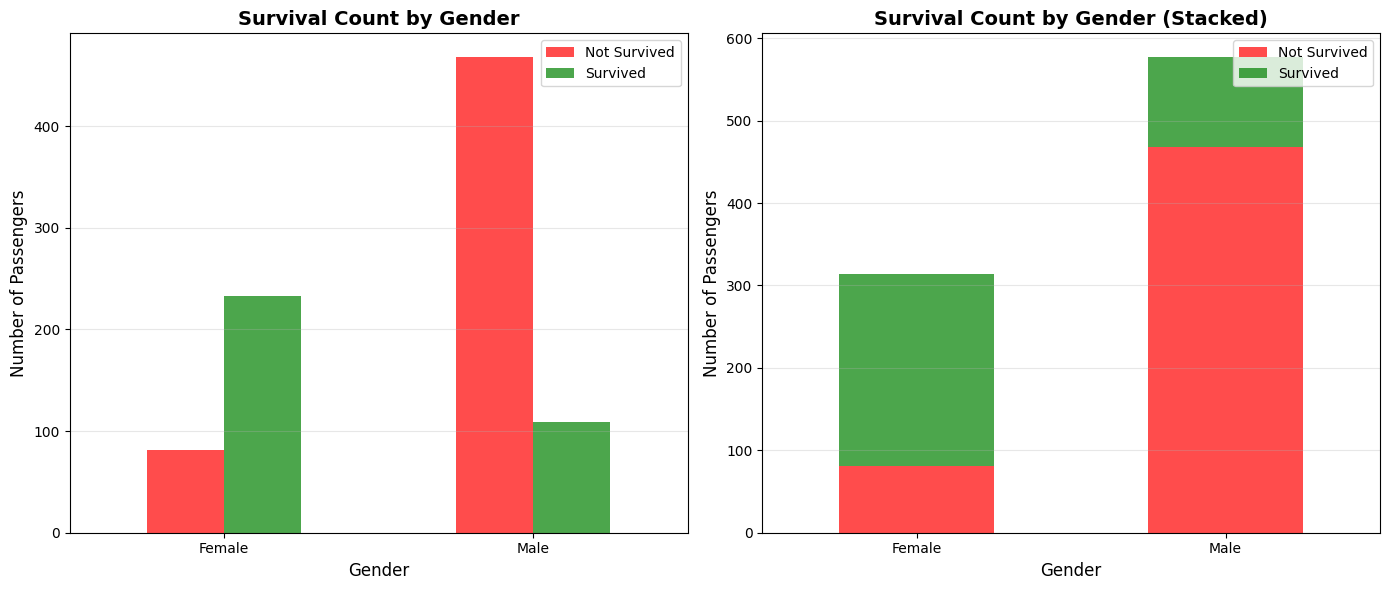


Survival Statistics by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109

Survival Rate by Gender:
Female: 74.20%
Male: 18.89%


In [10]:
# Bar plot: Survival count by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count survival by gender
survival_by_gender = train_df.groupby(['Sex', 'Survived']).size().unstack()

# Plot 1: Grouped bar chart
survival_by_gender.plot(kind='bar', ax=axes[0], color=['red', 'green'], alpha=0.7)
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Number of Passengers', fontsize=12)
axes[0].set_title('Survival Count by Gender', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0].legend(['Not Survived', 'Survived'], loc='upper right')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Stacked bar chart
survival_by_gender.plot(kind='bar', stacked=True, ax=axes[1], color=['red', 'green'], alpha=0.7)
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Number of Passengers', fontsize=12)
axes[1].set_title('Survival Count by Gender (Stacked)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['Not Survived', 'Survived'], loc='upper right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSurvival Statistics by Gender:")
print(survival_by_gender)
print("\nSurvival Rate by Gender:")
survival_rate = train_df.groupby('Sex')['Survived'].mean() * 100
print(f"Female: {survival_rate['female']:.2f}%")
print(f"Male: {survival_rate['male']:.2f}%")